In [14]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


df = pd.read_csv("data/new_data.csv")

In [15]:
df

,index,gender,car,reality,income_total,edu_type,family_type,DAYS_BIRTH,DAYS_EMPLOYED,occyp_type,begin_month,credit,occyp_group,guardian_status,adult_num
0,3,0,0,1,202500.0,2,Married,-15088,-2092,Sales staff,-37.0,0.0,5,0,2.0
1,7,1,0,1,270000.0,2,Married,-14896,-5420,Drivers,-53.0,0.0,4,0,2.0
2,12,0,1,1,157500.0,2,Married,-11938,-2162,Accountants,-60.0,0.0,3,0,2.0
3,15,1,1,1,157500.0,2,Married,-12859,-4056,Drivers,-60.0,0.0,4,0,2.0
4,22,0,0,0,157500.0,2,Civil marriage,-15198,-1357,Laborers,-22.0,0.0,4,0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3217,26370,0,0,1,247500.0,2,Widow,-20030,-2607,Cooking staff,-41.0,0.0,6,1,1.0
3218,26384,0,0,1,135000.0,2,Married,-11034,-2421,Laborers,-45.0,0.0,4,0,2.0
3219,26405,1,1,1,450000.0,4,Married,-18362,-2141,Medicine staff,-57.0,0.0,1,0,2.0
3220,26445,0,1,1,180000.0,3,Married,-13687,-4144,Laborers,-5.0,0.0,4,0,2.0


# 기본

# 기본

X_train 크기: (18519, 11)
y_train 크기: (18519,)
X_test 크기 (7938, 11)
y_test 크기 (7938,)
정확도: 0.6914840010078105
분류 보고서:
              precision    recall  f1-score   support

         0.0       0.41      0.20      0.27       951
         1.0       0.58      0.44      0.50      1872
         2.0       0.74      0.87      0.80      5115

    accuracy                           0.69      7938
   macro avg       0.58      0.51      0.53      7938
weighted avg       0.66      0.69      0.67      7938



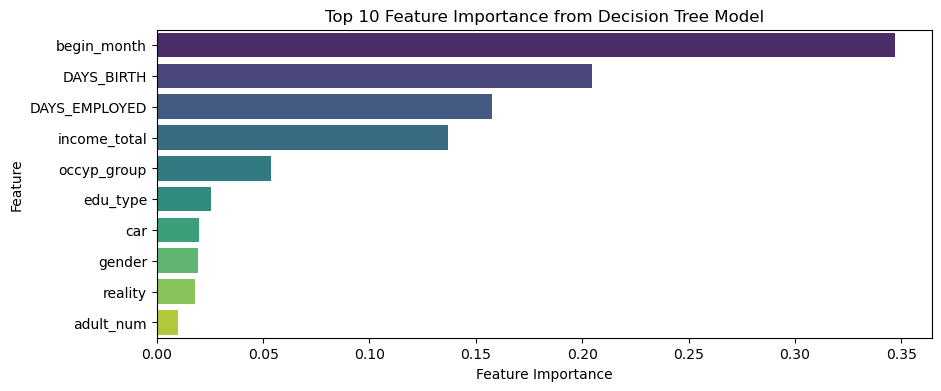

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 피처와 타겟 변수 분리 (이미 숫자로 변환된 컬럼은 인코딩 제외)
X = df.drop(columns=['credit', 'index', 'occyp_type', 'family_type', 'guardian_status'])
y = df['credit']

# 학습 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print("X_train 크기:", X_train.shape)
print("y_train 크기:", y_train.shape)
print("X_test 크기", X_test.shape)
print("y_test 크기", y_test.shape)

# 의사결정 나무 모델 학습
model = RandomForestClassifier(random_state=0, n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# 모델 평가
accuracy = accuracy_score(y_test, y_pred)
print("정확도:", accuracy)
print("분류 보고서:")
print(classification_report(y_test, y_pred))

# 변수 중요도 추출
feature_importances = model.feature_importances_

# 변수 중요도를 데이터프레임으로 정리
importance_df = pd.DataFrame({'feature': X.columns, 'importance': feature_importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

# 변수 중요도 시각화 상위 10
plt.figure(figsize=(10, 4))
sns.barplot(x='importance', y='feature', data=importance_df.head(10), palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance from Decision Tree Model')
plt.show()



# day_employee 제거

X_train 크기: (18519, 9)
y_train 크기: (18519,)
X_test 크기 (7938, 9)
y_test 크기 (7938,)
정확도: 0.6877047115142353
분류 보고서:
              precision    recall  f1-score   support

         0.0       0.39      0.17      0.23       951
         1.0       0.58      0.41      0.48      1872
         2.0       0.73      0.89      0.80      5115

    accuracy                           0.69      7938
   macro avg       0.57      0.49      0.50      7938
weighted avg       0.65      0.69      0.66      7938



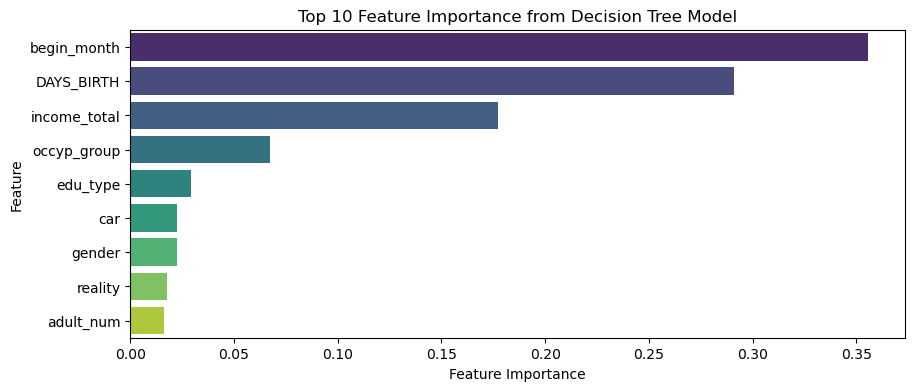

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 피처와 타겟 변수 분리 (이미 숫자로 변환된 컬럼은 인코딩 제외)
X = df.drop(columns=['credit', 'index', 'occyp_type', 'family_type', 'guardian_status','DAYS_EMPLOYED'])
y = df['credit']

# 학습 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print("X_train 크기:", X_train.shape)
print("y_train 크기:", y_train.shape)
print("X_test 크기", X_test.shape)
print("y_test 크기", y_test.shape)

# 의사결정 나무 모델 학습
model = RandomForestClassifier(random_state=0, n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# 모델 평가
accuracy = accuracy_score(y_test, y_pred)
print("정확도:", accuracy)
print("분류 보고서:")
print(classification_report(y_test, y_pred))

# 변수 중요도 추출
feature_importances = model.feature_importances_

# 변수 중요도를 데이터프레임으로 정리
importance_df = pd.DataFrame({'feature': X.columns, 'importance': feature_importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

# 변수 중요도 시각화 상위 10
plt.figure(figsize=(10, 4))
sns.barplot(x='importance', y='feature', data=importance_df.head(10), palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance from Decision Tree Model')
plt.show()



# credit 제거

In [9]:
df2 = df[df['credit'] != 1.0]

X_train 크기: (14133, 10)
y_train 크기: (14133,)
X_test 크기 (6057, 10)
y_test 크기 (6057,)


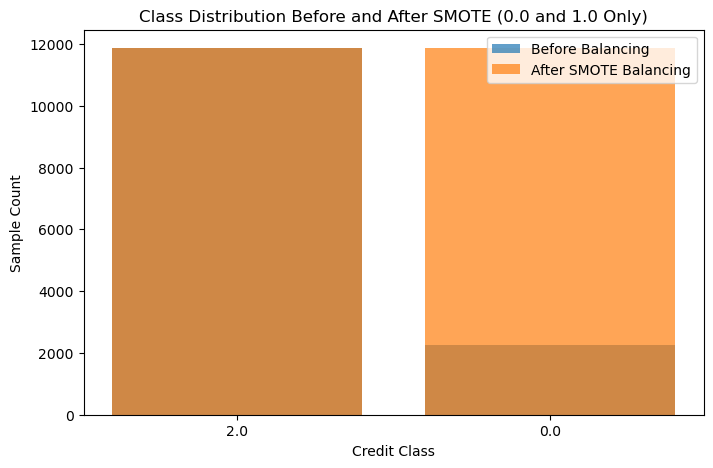

Classification Report:
              precision    recall  f1-score   support

         0.0       0.46      0.43      0.45       956
         2.0       0.89      0.91      0.90      5101

    accuracy                           0.83      6057
   macro avg       0.68      0.67      0.67      6057
weighted avg       0.83      0.83      0.83      6057



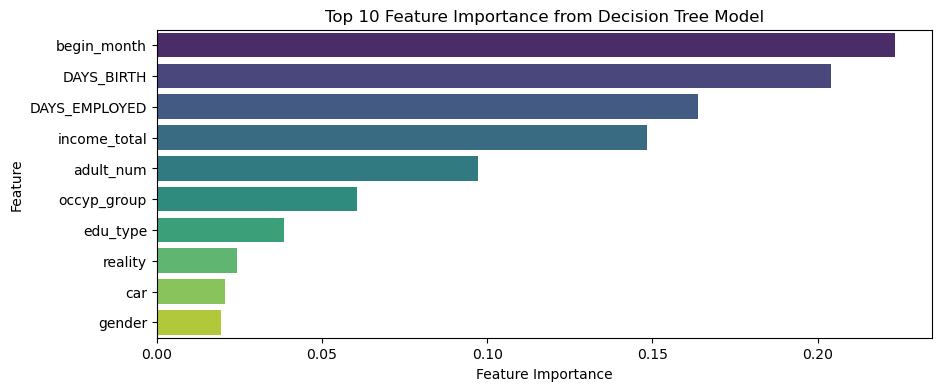

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 피처와 타겟 변수 분리 (이미 숫자로 변환된 컬럼은 인코딩 제외)
X = df2.drop(columns=['credit', 'index', 'occyp_type', 'family_type', 'guardian_status'])
y = df2['credit']

# 학습 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print("X_train 크기:", X_train.shape)
print("y_train 크기:", y_train.shape)
print("X_test 크기", X_test.shape)
print("y_test 크기", y_test.shape)


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# SMOTE 적용 전후의 클래스 분포 확인
before_counts = y_train.value_counts()
after_counts = pd.Series(y_train_smote).value_counts()

# 시각화
plt.figure(figsize=(8, 5))
plt.bar(before_counts.index.astype(str), before_counts.values, alpha=0.7, label='Before Balancing')
plt.bar(after_counts.index.astype(str), after_counts.values, alpha=0.7, label='After SMOTE Balancing')
plt.xlabel('Credit Class')
plt.ylabel('Sample Count')
plt.title('Class Distribution Before and After SMOTE (0.0 and 1.0 Only)')
plt.legend()
plt.show()

# 랜덤 포레스트 모델 학습
model = RandomForestClassifier(random_state=0, n_estimators=100)
model.fit(X_train_smote, y_train_smote)

# 테스트 데이터 예측
y_pred = model.predict(X_test)

# 모델 평가
print("Classification Report:")
print(classification_report(y_test, y_pred))


# 변수 중요도 추출
feature_importances = model.feature_importances_

# 변수 중요도를 데이터프레임으로 정리
importance_df = pd.DataFrame({'feature': X.columns, 'importance': feature_importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

# 변수 중요도 시각화 상위 10
plt.figure(figsize=(10, 4))
sns.barplot(x='importance', y='feature', data=importance_df.head(10), palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance from Decision Tree Model')
plt.show()


In [13]:
df2['credit'].value_counts()

2.0    16968
0.0     3222
Name: credit, dtype: int64

# credit + day_employee 제거

X_train 크기: (6642, 9)
y_train 크기: (6642,)
X_test 크기 (2847, 9)
y_test 크기 (2847,)
정확도: 0.7154899894625922
분류 보고서:
              precision    recall  f1-score   support

         0.0       0.61      0.42      0.50       950
         1.0       0.75      0.86      0.80      1897

    accuracy                           0.72      2847
   macro avg       0.68      0.64      0.65      2847
weighted avg       0.70      0.72      0.70      2847



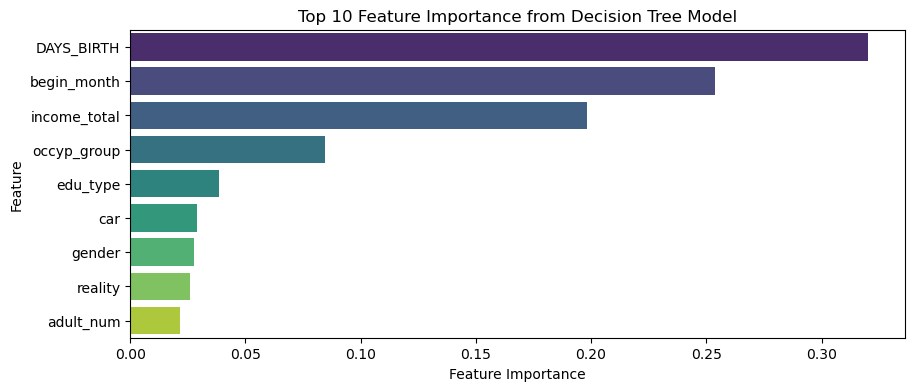

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 피처와 타겟 변수 분리 (이미 숫자로 변환된 컬럼은 인코딩 제외)
X = df2.drop(columns=['credit', 'index', 'occyp_type', 'family_type', 'guardian_status','DAYS_EMPLOYED'])
y = df2['credit']

# 학습 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print("X_train 크기:", X_train.shape)
print("y_train 크기:", y_train.shape)
print("X_test 크기", X_test.shape)
print("y_test 크기", y_test.shape)

# 의사결정 나무 모델 학습
model = RandomForestClassifier(random_state=0, n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# 모델 평가
accuracy = accuracy_score(y_test, y_pred)
print("정확도:", accuracy)
print("분류 보고서:")
print(classification_report(y_test, y_pred))

# 변수 중요도 추출
feature_importances = model.feature_importances_

# 변수 중요도를 데이터프레임으로 정리
importance_df = pd.DataFrame({'feature': X.columns, 'importance': feature_importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

# 변수 중요도 시각화 상위 10
plt.figure(figsize=(10, 4))
sns.barplot(x='importance', y='feature', data=importance_df.head(10), palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance from Decision Tree Model')
plt.show()



# credit,employee 제거 후 밸런싱

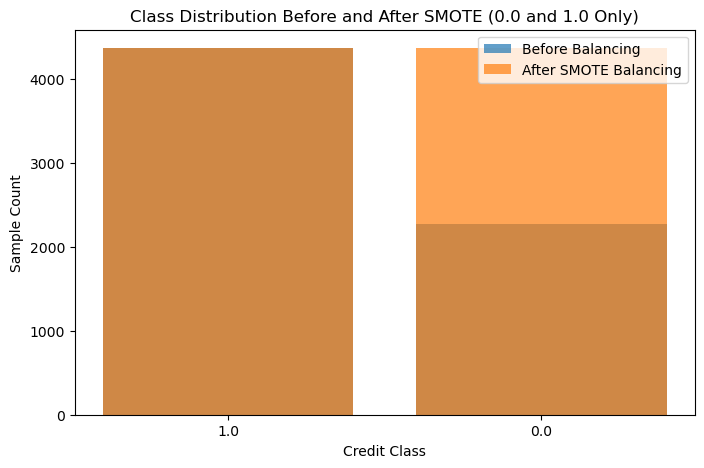

Classification Report:
              precision    recall  f1-score   support

         0.0       0.55      0.53      0.54       950
         1.0       0.77      0.78      0.78      1897

    accuracy                           0.70      2847
   macro avg       0.66      0.66      0.66      2847
weighted avg       0.70      0.70      0.70      2847



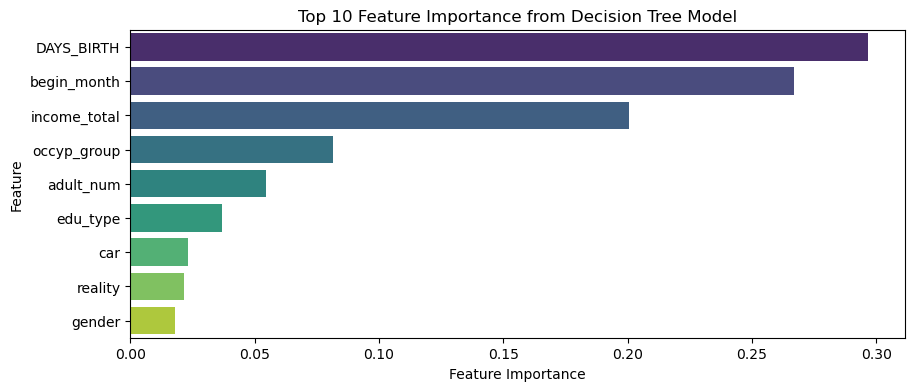

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 데이터 준비: credit == 2.0 제거
df_filtered = df2[df2['credit'] != 2.0]

# 주요 변수와 타겟 분리
X = df2.drop(columns=['credit', 'index', 'occyp_type', 'family_type', 'guardian_status','DAYS_EMPLOYED'])
y = df_filtered['credit']

# 학습 및 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# SMOTE 적용
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# SMOTE 적용 전후의 클래스 분포 확인
before_counts = y_train.value_counts()
after_counts = pd.Series(y_train_smote).value_counts()

# 시각화
plt.figure(figsize=(8, 5))
plt.bar(before_counts.index.astype(str), before_counts.values, alpha=0.7, label='Before Balancing')
plt.bar(after_counts.index.astype(str), after_counts.values, alpha=0.7, label='After SMOTE Balancing')
plt.xlabel('Credit Class')
plt.ylabel('Sample Count')
plt.title('Class Distribution Before and After SMOTE (0.0 and 1.0 Only)')
plt.legend()
plt.show()

# 랜덤 포레스트 모델 학습
model = RandomForestClassifier(random_state=0, n_estimators=100)
model.fit(X_train_smote, y_train_smote)

# 테스트 데이터 예측
y_pred = model.predict(X_test)

# 모델 평가
print("Classification Report:")
print(classification_report(y_test, y_pred))


# 변수 중요도 추출
feature_importances = model.feature_importances_

# 변수 중요도를 데이터프레임으로 정리
importance_df = pd.DataFrame({'feature': X.columns, 'importance': feature_importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

# 변수 중요도 시각화 상위 10
plt.figure(figsize=(10, 4))
sns.barplot(x='importance', y='feature', data=importance_df.head(10), palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance from Decision Tree Model')
plt.show()

